# MECH_ENG 395 Final Project
---

## Architecture
The Deep Recurrent Neural Network model predicts the **ABP (arterial blood pressure) waveform** from synchronised **PPG + ECG** signals.



# Setup
data_loader.py modified from https://github.com/powhwee/bp-measure/tree/main

core algorithm for deep LSTM network derived from https://github.com/psu1/DeepRNN/tree/master

In [1]:
import sys, os, math, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/ME395"

import sys
sys.path.append(PROJECT_DIR)

from data_loader import UCILoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Mounted at /content/drive
Using device: cuda


# Configurations

In [2]:
DATA_PATH    = f"{PROJECT_DIR}/Part_1.mat"
MAX_WINDOWS  = 2500 # NONE loads all windows,

# model hyper-parameters
INPUT_SIZE   = 2      # PPG + ECG
HIDDEN_SIZE  = 64     # units per LSTM layer
NUM_RES_LAYERS = 3    # residual LSTM layers on top of the BiLSTM
DROPOUT      = 0.2

# physics parameters
DT = 1/125
LAMBDA_WK = 0.1

# training parameters
BATCH_SIZE   = 64
EPOCHS       = 300
LR           = 1e-3
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.10

# reproducibility
SEED         = 35

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Dataset Wrapper

In [3]:
class BPDataset(Dataset):
    """Wraps UCILoader output into a PyTorch Dataset.

        X : FloatTensor (T, 2) -- PPG + ECG signals
        y : FloatTensor (T, 1) -- ABP waveform target

        N = number of windows/batch size
        T = number of samples per window (500 for 4 seconds sampled at 125 Hz)
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # X: (N, 2, T) -> (N, T, 2)
        self.X = torch.from_numpy(X).permute(0, 2, 1).float()
        # y: (N, T) -> (N, T, 1)
        self.y = torch.from_numpy(y).unsqueeze(-1).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def load_dataset(path: str, max_windows: Optional[int] = None):
    """Load .mat file and return a BPDataset."""
    loader = UCILoader(verbose=True)
    X, y = loader.load_part(path, max_windows=max_windows)

    # z-score normalization of PPG and ECG input signals
    x_mean = X.mean(axis=(0, 2), keepdims=True)
    x_std  = X.std(axis=(0, 2), keepdims=True) + 1e-8

    X = (X - x_mean) / x_std

    print(f"\nLoaded → X: {X.shape}, y: {y.shape}")
    print(f"Input mean: {x_mean.flatten()}")
    print(f"Input std : {x_std.flatten()}")
    return BPDataset(X, y)


def split_dataset(dataset: BPDataset,
                  val_split: float = 0.15,
                  test_split: float = 0.10,
                  seed=None):
    """Split into train / val / test subsets."""
    n = len(dataset)
    n_test  = int(n * test_split)
    n_val   = int(n * val_split)
    n_train = n - n_val - n_test
    generator = torch.Generator().manual_seed(seed)
    return random_split(dataset, [n_train, n_val, n_test], generator=generator)


# Load and Split Dataset

In [4]:
dataset = load_dataset(DATA_PATH, max_windows=MAX_WINDOWS)

train_set, val_set, test_set = split_dataset(dataset, VAL_SPLIT, TEST_SPLIT, SEED)
print(f"Split  →  train: {len(train_set)}  val: {len(val_set)}  test: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


Loading /content/drive/MyDrive/ME395/Part_1.mat...
Found 3000 patient records (HDF5 format)


Processing patients:   2%|▏         | 46/3000 [00:02<03:01, 16.24it/s]


Loaded → X: (2500, 2, 500), y: (2500, 500)
Input mean: [1.1626168 0.2723773]
Input std : [0.8387351  0.17128515]
Split  →  train: 1875  val: 375  test: 250


# Long Short-Term Memory Network
```
Input  (N, T, 2)  ← PPG + ECG channels
  │
  ▼
BiLSTM  (bottom layer, forward/backward concatenated)
  │
  ▼
LSTM Layer 1  (+ residual connection)
  │
  ▼
LSTM Layer 2  (+ residual connection)
  │
  ▼
LSTM Layer 3  (+ residual connection)
  │
  ▼
Linear → Output  (N, T, 1)  ← ABP waveform
```

In [5]:
# deep LSTM network layers
class ResidualLSTMLayer(nn.Module):
    """Single unidirectional LSTM layer with a residual connection.

    Input and output both have shape (N, T, hidden_size).
    If the input feature dimension differs from hidden_size, a learned linear
    projection is added to the residual path.
    """
    def __init__(self, hidden_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)         # (N, T, H)
        return x + self.dropout(out)


class DeepLSTM(nn.Module):
    """
    Architecture:
        1. BiLSTM  (bottom layer)
        2. N × ResidualLSTMLayer
        3. Linear projection → 1 output per timestep (ABP waveform)

    Args:
        input_size   : number of input channels (2 = PPG + ECG)
        hidden_size  : LSTM hidden units per direction
        num_res_layers: number of residual LSTM layers above the BiLSTM
        dropout      : dropout probability applied after each LSTM layer
    """
    def __init__(self, input_size, hidden_size, num_res_layers, dropout):
        super().__init__()

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.bilstm_dropout = nn.Dropout(dropout)
        # BiLSTM output is 2*hidden_size; project down to hidden_size
        self.bilstm_proj = nn.Linear(hidden_size * 2, hidden_size)
        self.bilstm_norm = nn.LayerNorm(hidden_size)

        # LSTM layers with residual connections
        self.res_layers = nn.ModuleList([
            ResidualLSTMLayer(hidden_size, dropout)
            for _ in range(num_res_layers)
        ])

        # Linear output projection
        self.output_proj = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (N, T, input_size)
        Returns:
            out : (N, T, 1)
        """
        # BiLSTM
        h, _ = self.bilstm(x)                        # (N, T, 2*H)
        h = self.bilstm_dropout(h)
        h = self.bilstm_norm(self.bilstm_proj(h))    # (N, T, H)

        # Residual LSTM stack
        for layer in self.res_layers:
            h = layer(h)                             # (N, T, H)

        # Per-timestep ABP prediction
        return self.output_proj(h)                   # (N, T, 1)


# check
model = DeepLSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_res_layers=NUM_RES_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

# Print the architecture and parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total learnable parameters: {total_params}\n")
for name, p in model.named_parameters():
    print(f"  {name:6s}  shape {str(list(p.shape)):12s}  ({p.numel():4d} params)")

Total learnable parameters: 143489

  bilstm.weight_ih_l0  shape [256, 2]      ( 512 params)
  bilstm.weight_hh_l0  shape [256, 64]     (16384 params)
  bilstm.bias_ih_l0  shape [256]         ( 256 params)
  bilstm.bias_hh_l0  shape [256]         ( 256 params)
  bilstm.weight_ih_l0_reverse  shape [256, 2]      ( 512 params)
  bilstm.weight_hh_l0_reverse  shape [256, 64]     (16384 params)
  bilstm.bias_ih_l0_reverse  shape [256]         ( 256 params)
  bilstm.bias_hh_l0_reverse  shape [256]         ( 256 params)
  bilstm_proj.weight  shape [64, 128]     (8192 params)
  bilstm_proj.bias  shape [64]          (  64 params)
  bilstm_norm.weight  shape [64]          (  64 params)
  bilstm_norm.bias  shape [64]          (  64 params)
  res_layers.0.lstm.weight_ih_l0  shape [256, 64]     (16384 params)
  res_layers.0.lstm.weight_hh_l0  shape [256, 64]     (16384 params)
  res_layers.0.lstm.bias_ih_l0  shape [256]         ( 256 params)
  res_layers.0.lstm.bias_hh_l0  shape [256]         ( 256 

# Windkessel Condition

In [6]:
class WindKesselParams(nn.Module):
  def __init__(self):
    super().__init__()

    # define peripheral resistance (R) and arterial compliance as learnable params
    self.log_R = nn.Parameter(torch.tensor(0.0))
    self.log_C = nn.Parameter(torch.tensor(0.0))

  def forward(self):
    R = torch.exp(self.log_R)
    C = torch.exp(self.log_C)
    return R, C

# Physics-Informed Loss

In [7]:
def wk_loss(P,Q,R,C,dt):
  dPdt = (P[:,1:,:] - P[:,:-1,:]) / dt
  residual = (C*dPdt + P[:,:-1,:]/R - Q[:,:-1,:])
  return torch.mean(residual**2)

# Physics-Informed DeepLSTM

In [8]:
class DeepLSTMPhysics(nn.Module):
    def __init__(self, input_size, hidden_size, num_res_layers, dropout):
        super().__init__()

        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )

        self.bilstm_dropout = nn.Dropout(dropout)
        self.bilstm_proj = nn.Linear(hidden_size * 2, hidden_size)
        self.bilstm_norm = nn.LayerNorm(hidden_size)

        self.res_layers = nn.ModuleList([
            ResidualLSTMLayer(hidden_size, dropout)
            for _ in range(num_res_layers)
        ])


        self.output_proj = nn.Linear(hidden_size, 1)
        self.flow_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h, _ = self.bilstm(x)
        h = self.bilstm_dropout(h)
        h = self.bilstm_norm(self.bilstm_proj(h))

        for layer in self.res_layers:
            h = layer(h)

        abp_pred = self.output_proj(h)
        flow_pred = self.flow_head(h)

        return abp_pred, flow_pred


# Utilities

In [9]:
def sbp_dbp_rmse(pred: torch.Tensor, target: torch.Tensor):
    """Compute RMSE for SBP (max) and DBP (min) per window."""
    pred_np   = pred.squeeze(-1).detach().cpu().numpy()
    target_np = target.squeeze(-1).detach().cpu().numpy()
    sbp_pred, sbp_true = pred_np.max(axis=1), target_np.max(axis=1)
    dbp_pred, dbp_true = pred_np.min(axis=1), target_np.min(axis=1)
    sbp_rmse = np.sqrt(np.mean((sbp_pred - sbp_true) ** 2))
    dbp_rmse = np.sqrt(np.mean((dbp_pred - dbp_true) ** 2))
    return sbp_rmse, dbp_rmse


def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * len(xb)
            all_preds.append(pred)
            all_targets.append(yb)

    avg_loss = total_loss / len(loader.dataset)
    preds_cat   = torch.cat(all_preds,   dim=0)
    targets_cat = torch.cat(all_targets, dim=0)
    sbp_rmse, dbp_rmse = sbp_dbp_rmse(preds_cat, targets_cat)

    return avg_loss, sbp_rmse, dbp_rmse

def run_epoch_physics(
    model,
    loader,
    criterion,
    wk_params,
    lambda_wk,
    optimizer=None,
    device=DEVICE,
):

    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    data_loss_total = 0.0
    wk_loss_total = 0.0

    all_preds = []
    all_targets = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            P, Q = model(xb)
            R, C = wk_params()

            data_loss = criterion(P, yb)
            phys_loss = wk_loss(P, Q, R, C, DT)
            loss = data_loss + lambda_wk * phys_loss

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            batch_size = len(xb)

            total_loss += loss.item() * batch_size
            data_loss_total += data_loss.item() * batch_size
            wk_loss_total += phys_loss.item() * batch_size

            all_preds.append(P)
            all_targets.append(yb)

    n = len(loader.dataset)

    preds_cat = torch.cat(all_preds, dim=0)
    targets_cat = torch.cat(all_targets, dim=0)

    sbp_rmse, dbp_rmse = sbp_dbp_rmse(preds_cat,targets_cat)

    return (
        total_loss / n,
        data_loss_total / n,
        wk_loss_total / n,
        sbp_rmse,
        dbp_rmse,
    )


# Training Loop (Vanilla)

In [10]:
def train(model, train_loader, val_loader, epochs, lr, device=DEVICE):
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {"train_loss": [],
               "val_loss": [],
               "val_sbp_rmse": [],
               "val_dbp_rmse": []}

    best_val_loss = float("inf")
    best_state    = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_sbp, tr_dbp = run_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_sbp, vl_dbp = run_epoch(model, val_loader,   criterion, None,      device)

        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["val_sbp_rmse"].append(vl_sbp)
        history["val_dbp_rmse"].append(vl_dbp)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d}/{epochs}  "
                f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
                f"SBP_RMSE={vl_sbp:.2f} mmHg DBP_RMSE={vl_dbp:.2f} mmHg"
            )

    # Restore best weights
    model.load_state_dict(best_state)
    print(f"\nBest val_loss = {best_val_loss:.4f}")
    return history

baseline_model = DeepLSTM(INPUT_SIZE,HIDDEN_SIZE,NUM_RES_LAYERS,DROPOUT).to(DEVICE)
baseline_history = train(baseline_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE)


Epoch   1/300  train_loss=6215.7366  val_loss=4888.1462  SBP_RMSE=110.99 mmHg DBP_RMSE=51.50 mmHg
Epoch   5/300  train_loss=1614.2375  val_loss=1304.9993  SBP_RMSE=73.56 mmHg DBP_RMSE=22.18 mmHg
Epoch  10/300  train_loss=275.6189  val_loss=207.7102  SBP_RMSE=33.12 mmHg DBP_RMSE=9.11 mmHg
Epoch  15/300  train_loss=89.2392  val_loss=79.2628  SBP_RMSE=13.01 mmHg DBP_RMSE=7.68 mmHg
Epoch  20/300  train_loss=82.2384  val_loss=76.4583  SBP_RMSE=11.54 mmHg DBP_RMSE=7.18 mmHg
Epoch  25/300  train_loss=78.6651  val_loss=73.7860  SBP_RMSE=10.91 mmHg DBP_RMSE=5.83 mmHg
Epoch  30/300  train_loss=75.7630  val_loss=74.1535  SBP_RMSE=10.59 mmHg DBP_RMSE=5.97 mmHg
Epoch  35/300  train_loss=73.3421  val_loss=66.9393  SBP_RMSE=9.90 mmHg DBP_RMSE=5.25 mmHg
Epoch  40/300  train_loss=71.3497  val_loss=66.4861  SBP_RMSE=9.60 mmHg DBP_RMSE=4.97 mmHg
Epoch  45/300  train_loss=69.0909  val_loss=63.1312  SBP_RMSE=9.54 mmHg DBP_RMSE=4.85 mmHg
Epoch  50/300  train_loss=65.7840  val_loss=62.0859  SBP_RMSE=9.26 mmH

# Training Loop (Physics)

In [11]:

def train_physics(model, train_loader, val_loader, epochs, lr, lambda_wk, device=DEVICE):
    wk_params = WindKesselParams().to(device)
    criterion = nn.MSELoss()
    optimizer = Adam(list(model.parameters())+list(wk_params.parameters()), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {"train_total":[],
               "train_data":[],
               "train_wk":[],
               "val_total":[],
               "val_data":[],
               "val_wk":[],
               "val_sbp_rmse": [],
               "val_dbp_rmse": []}

    best_val_loss = float("inf")
    best_state = None
    best_wk_state = None

    for epoch in range(1, epochs + 1):
      tr_total, tr_data, tr_wk, tr_sbp, tr_dbp = run_epoch_physics(model, train_loader, criterion, wk_params, lambda_wk, optimizer,device)
      vl_total, vl_data, vl_wk, vl_sbp, vl_dbp = run_epoch_physics(model, val_loader, criterion, wk_params, lambda_wk, None,device)

      scheduler.step(vl_total)

      history["train_total"].append(tr_total)
      history["train_data"].append(tr_data)
      history["train_wk"].append(tr_wk)

      history["val_total"].append(vl_total)
      history["val_data"].append(vl_data)
      history["val_wk"].append(vl_wk)

      history["val_sbp_rmse"].append(vl_sbp)
      history["val_dbp_rmse"].append(vl_dbp)

      if vl_total < best_val_loss:
        best_val_loss = vl_total
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_wk_state = {k: v.cpu().clone() for k, v in wk_params.state_dict().items()}

      if epoch % 5 == 0 or epoch == 1:
          print(
              f"Epoch {epoch:3d}/{epochs}  "
              f"train_total={tr_total:.4f}  "
              f"val_total={vl_total:.4f}  "
              f"data={vl_data:.4f}  "
              f"wk={vl_wk:.4f}  "
              f"SBP_RMSE={vl_sbp:.2f} mmHg "
              f"DBP_RMSE={vl_dbp:.2f} mmHg"
          )

    model.load_state_dict(best_state)
    wk_params.load_state_dict(best_wk_state)

    print(f"\\nBest val_total = {best_val_loss:.4f}")

    return history, wk_params

physics_model = DeepLSTMPhysics(INPUT_SIZE,HIDDEN_SIZE,NUM_RES_LAYERS,DROPOUT).to(DEVICE)
physics_history, wk_params = train_physics(physics_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, lambda_wk=LAMBDA_WK, device=DEVICE)


Epoch   1/300  train_total=6796.3403  val_total=5315.6716  data=5263.0337  wk=526.3797  SBP_RMSE=113.68 mmHg DBP_RMSE=53.88 mmHg
Epoch   5/300  train_total=3493.7137  val_total=2352.0070  data=2330.4593  wk=215.4776  SBP_RMSE=87.36 mmHg DBP_RMSE=33.75 mmHg
Epoch  10/300  train_total=1472.6450  val_total=781.6360  data=773.1146  wk=85.2137  SBP_RMSE=61.70 mmHg DBP_RMSE=9.51 mmHg
Epoch  15/300  train_total=792.7977  val_total=482.8384  data=473.4416  wk=93.9677  SBP_RMSE=50.46 mmHg DBP_RMSE=11.32 mmHg
Epoch  20/300  train_total=604.1001  val_total=412.8001  data=392.2879  wk=205.1219  SBP_RMSE=44.97 mmHg DBP_RMSE=16.13 mmHg
Epoch  25/300  train_total=504.1726  val_total=388.1514  data=362.0737  wk=260.7775  SBP_RMSE=42.97 mmHg DBP_RMSE=17.51 mmHg
Epoch  30/300  train_total=457.5223  val_total=375.4818  data=347.1449  wk=283.3695  SBP_RMSE=41.68 mmHg DBP_RMSE=17.59 mmHg
Epoch  35/300  train_total=414.8572  val_total=350.4068  data=315.3879  wk=350.1891  SBP_RMSE=39.23 mmHg DBP_RMSE=17.24 

# Training Loss Curves

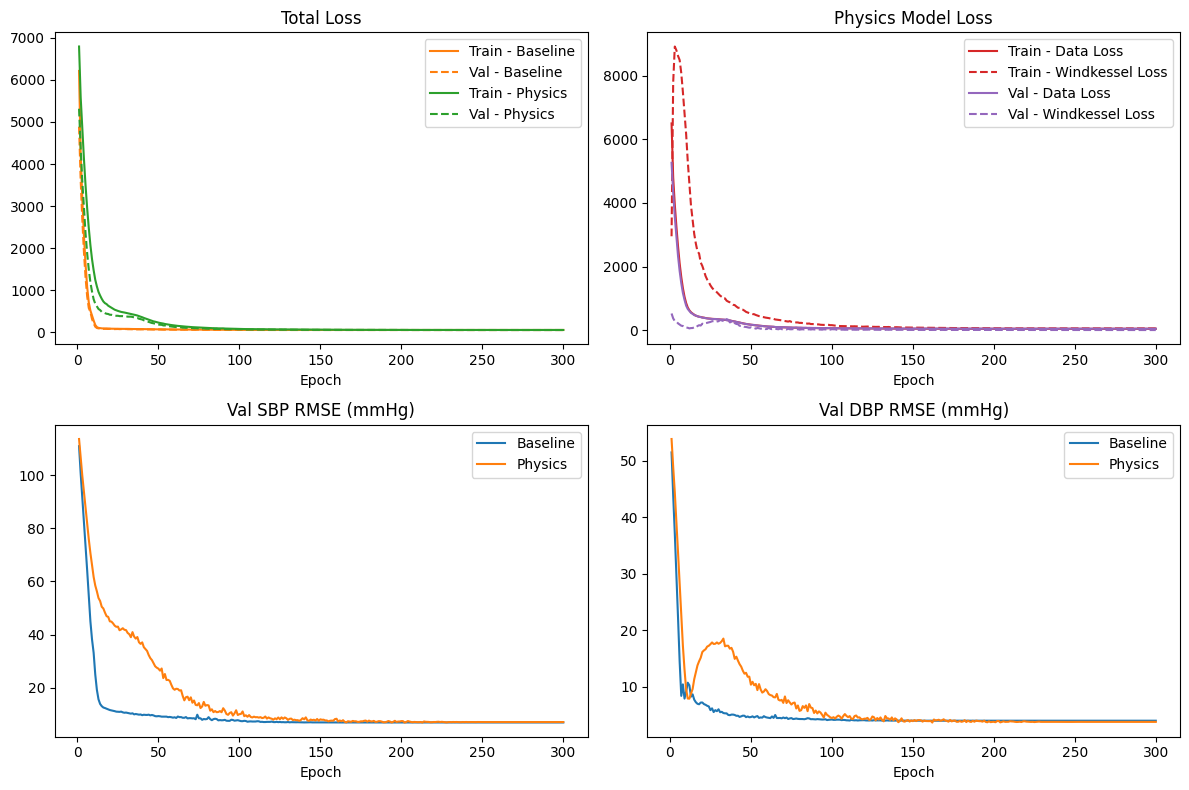

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs_range = range(1, len(baseline_history["train_loss"]) + 1)

# total loss plot
axes[0,0].plot(epochs_range, baseline_history["train_loss"],
             label="Train - Baseline", color = 'C1', linestyle = '-')
axes[0,0].plot(epochs_range, baseline_history["val_loss"],
             label="Val - Baseline", color = 'C1', linestyle = '--')
axes[0,0].plot(epochs_range, physics_history["train_total"],
             label="Train - Physics", color = 'C2', linestyle = '-')
axes[0,0].plot(epochs_range, physics_history["val_total"],
             label="Val - Physics", color = 'C2', linestyle = '--')
axes[0,0].set_title("Total Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

# physics loss plot
axes[0,1].plot(epochs_range, physics_history["train_data"],
             label = "Train - Data Loss", color = 'C3', linestyle = '-')
axes[0,1].plot(epochs_range, physics_history["train_wk"],
             label = "Train - Windkessel Loss", color = 'C3', linestyle = '--')
axes[0,1].plot(epochs_range, physics_history["val_data"],
             label = "Val - Data Loss", color = 'C4', linestyle = '-')
axes[0,1].plot(epochs_range, physics_history["val_wk"],
             label = "Val - Windkessel Loss", color = 'C4', linestyle = '--')
axes[0,1].set_title("Physics Model Loss"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

# SBP RMSE
axes[1,0].plot(epochs_range, baseline_history["val_sbp_rmse"], label="Baseline")
axes[1,0].plot(epochs_range, physics_history["val_sbp_rmse"], label = "Physics")
axes[1,0].set_title("Val SBP RMSE (mmHg)"); axes[1,0].set_xlabel("Epoch")
axes[1,0].legend()

# DBP RMSE
axes[1,1].plot(epochs_range, baseline_history["val_dbp_rmse"], label = "Baseline")
axes[1,1].plot(epochs_range, physics_history["val_dbp_rmse"], label= "Physics")
axes[1,1].set_title("Val DBP RMSE (mmHg)"); axes[1,1].set_xlabel("Epoch")
axes[1,1].legend()

plt.tight_layout()
plt.show()


# Evaluate on Test Set

In [14]:
baseline_model.eval()
physics_model.eval()

baseline_test_loss, baseline_test_sbp, baseline_test_dbp = run_epoch(baseline_model, test_loader, nn.MSELoss(), device=DEVICE)
baseline_test_rmse = math.sqrt(baseline_test_loss)

(physics_test_loss,
 physics_test_data,
 physics_test_wk,
 physics_test_sbp,
 physics_test_dbp) = run_epoch_physics(physics_model, test_loader, nn.MSELoss(), wk_params, LAMBDA_WK, device=DEVICE)
physics_test_rmse = math.sqrt(physics_test_loss)

print("=" * 60)
print("Baseline DeepLSTM")
print("=" * 60)
print(f"Test waveform RMSE : {baseline_test_rmse:.4f} mmHg")
print(f"Test SBP RMSE      : {baseline_test_sbp:.4f} mmHg")
print(f"Test DBP RMSE      : {baseline_test_dbp:.4f} mmHg")

print("\n" + "=" * 60)
print("Physics-Informed DeepLSTM")
print("=" * 60)
print(f"Test waveform RMSE : {physics_test_rmse:.4f} mmHg")
print(f"Test SBP RMSE      : {physics_test_sbp:.4f} mmHg")
print(f"Test DBP RMSE      : {physics_test_dbp:.4f} mmHg")
print(f"Test data loss     : {physics_test_data:.4f}")
print(f"Test WK loss       : {physics_test_wk:.4f}")


Baseline DeepLSTM
Test waveform RMSE : 6.5687 mmHg
Test SBP RMSE      : 6.5551 mmHg
Test DBP RMSE      : 3.8390 mmHg

Physics-Informed DeepLSTM
Test waveform RMSE : 6.6301 mmHg
Test SBP RMSE      : 6.1121 mmHg
Test DBP RMSE      : 3.6331 mmHg
Test data loss     : 43.3275
Test WK loss       : 6.3007


# Plots

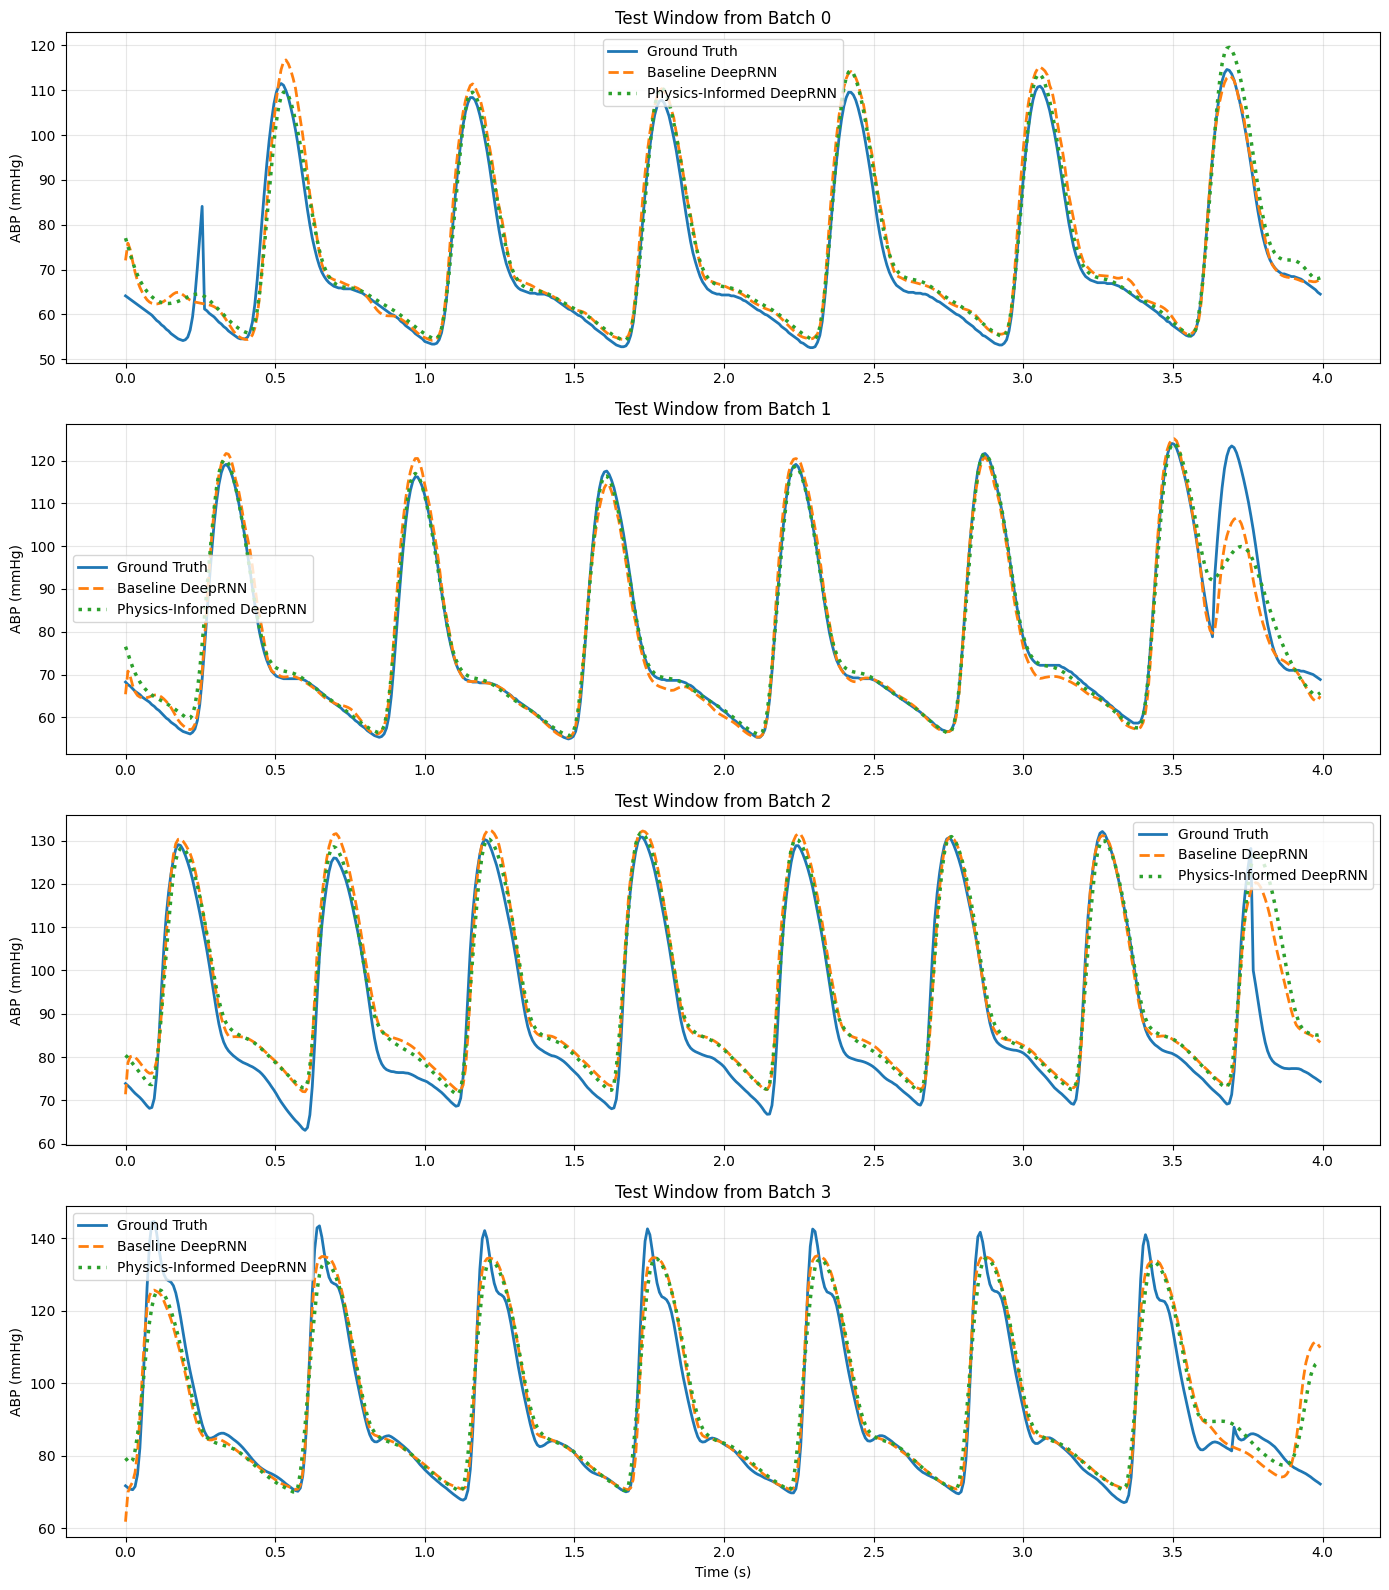

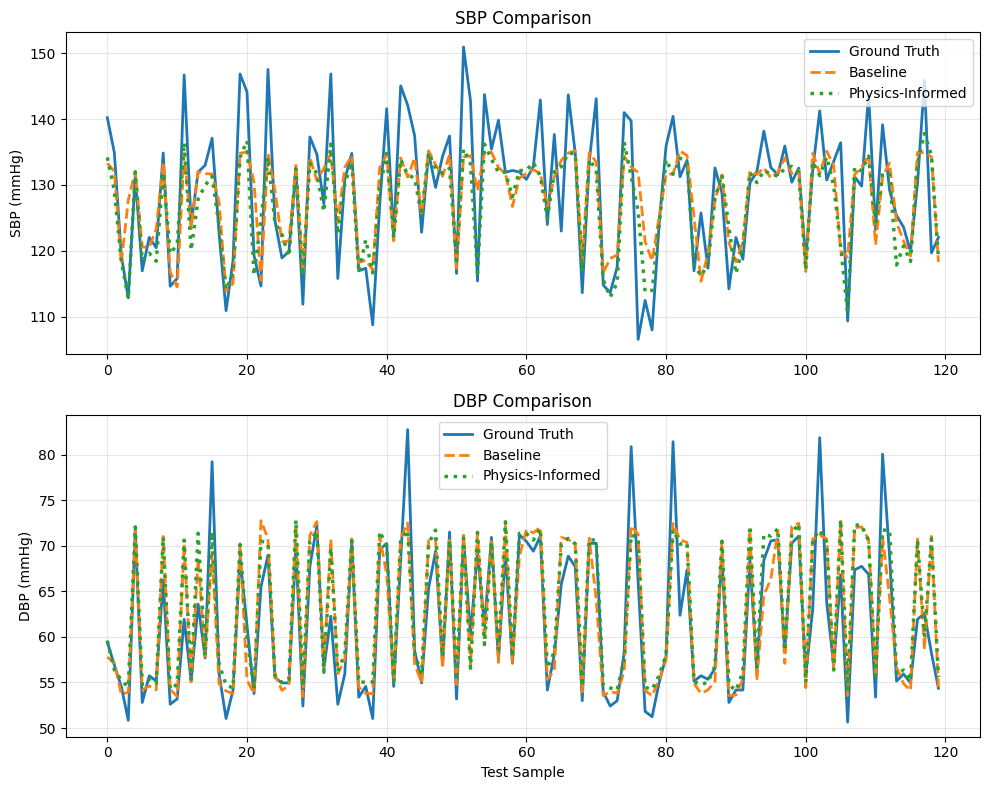

In [15]:
baseline_model.eval()
physics_model.eval()

# ABP waveforms
examples = []

# bp and dbp comparisons
all_true_sbp = []
all_true_dbp = []

all_baseline_sbp = []
all_baseline_dbp = []

all_physics_sbp = []
all_physics_dbp = []

with torch.no_grad():
    for xb, yb in test_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred_baseline = baseline_model(xb)
        pred_physics  = physics_model(xb)[0]

        # Save a few example windows
        if len(examples) < 5:
            idx = np.random.randint(len(xb))

            examples.append({
                "truth": yb[idx, :, 0].cpu().numpy(),
                "baseline": pred_baseline[idx, :, 0].cpu().numpy(),
                "physics": pred_physics[idx, :, 0].cpu().numpy(),
                "batch": len(examples)
            })

        y_true = yb.squeeze(-1).cpu().numpy()
        y_base = pred_baseline.squeeze(-1).cpu().numpy()
        y_phys = pred_physics.squeeze(-1).cpu().numpy()

        all_true_sbp.extend(y_true.max(axis=1))
        all_true_dbp.extend(y_true.min(axis=1))

        all_baseline_sbp.extend(y_base.max(axis=1))
        all_baseline_dbp.extend(y_base.min(axis=1))

        all_physics_sbp.extend(y_phys.max(axis=1))
        all_physics_dbp.extend(y_phys.min(axis=1))

    all_true_sbp = np.array(all_true_sbp)
    all_true_dbp = np.array(all_true_dbp)

    all_baseline_sbp = np.array(all_baseline_sbp)
    all_baseline_dbp = np.array(all_baseline_dbp)

    all_physics_sbp = np.array(all_physics_sbp)
    all_physics_dbp = np.array(all_physics_dbp)


T = examples[0]["truth"].shape[0]
fs = 125
t = np.arange(T) / fs

fig, axes = plt.subplots(len(examples), 1,figsize=(14, 4*len(examples)))
if len(examples) == 1:
    axes = [axes]
for ax, ex in zip(axes, examples):
    ax.plot(t, ex["truth"], label="Ground Truth", linewidth=2)
    ax.plot(t,ex["baseline"],"--",label="Baseline DeepRNN",linewidth=2)
    ax.plot(t, ex["physics"],":",label="Physics-Informed DeepRNN",linewidth=2.5)

    ax.set_title(f"Test Window from Batch {ex['batch']}")
    ax.set_ylabel("ABP (mmHg)")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


# SBP and DBP Plot
N = 120  # number of samples
cycles = np.arange(N)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# SBP
axs[0].plot(cycles, all_true_sbp[:N], label='Ground Truth', linewidth=2)
axs[0].plot(cycles, all_baseline_sbp[:N], '--', label='Baseline', linewidth=2)
axs[0].plot(cycles, all_physics_sbp[:N], ':', label='Physics-Informed', linewidth=2.5)

axs[0].set_ylabel('SBP (mmHg)')
axs[0].set_title('SBP Comparison')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ---------------- DBP ----------------
axs[1].plot(cycles, all_true_dbp[:N], label='Ground Truth', linewidth=2)
axs[1].plot(cycles, all_baseline_dbp[:N], '--', label='Baseline', linewidth=2)
axs[1].plot(cycles, all_physics_dbp[:N], ':', label='Physics-Informed', linewidth=2.5)

axs[1].set_ylabel('DBP (mmHg)')
axs[1].set_xlabel('Test Sample')
axs[1].set_title('DBP Comparison')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Save Model Checkpoint

In [ ]:
# manual edit
checkpoint = {
    "model_state_dict": model.state_dict(),
    "config": {
        "input_size"    : INPUT_SIZE,
        "hidden_size"   : HIDDEN_SIZE,
        "num_res_layers": NUM_RES_LAYERS,
        "dropout"       : DROPOUT,
    },

    # Physics-informed training settings
    "lambda_wk": LAMBDA_WK,
    "wk_params": wk_params,

    # Training history
    "history": physics_history,

    # Final test metrics
    "test_waveform_rmse": physics_test_rmse,
    "test_sbp_rmse": physics_test_sbp,
    "test_dbp_rmse": physics_test_dbp,
}

torch.save(checkpoint, "deepLSTM_physics.pt")
print("Checkpoint saved")

# # Reload model
# ckpt = torch.load("deeprnn_bp.pt", map_location="cpu")
# model = DeepRNN(**ckpt["config"])
# model.load_state_dict(ckpt["model_state_dict"])
# model.eval()
